<a href="https://colab.research.google.com/github/mts2705/An-lise-infeccoes-dengue-sp/blob/main/Exerc%C3%ADcio_final_aula_4_ajustado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dengue (2013 - 2023)

A dengue faz parte de um grupo de doenças denominadas arboviroses, que se caracterizam por serem causadas por vírus transmitidos por vetores artrópodes. No Brasil, o vetor da dengue é a fêmea do mosquito Aedes aegypti (significa "odioso do Egito"). Os vírus dengue (DENV) estão classificados cientificamente na família Flaviviridae e no gênero Flavivirus. Até o momento são conhecidos quatro sorotipos – DENV-1, DENV-2, DENV-3 e DENV-4 –, que apresentam distintos materiais genéticos (genótipos) e linhagens.

As evidências apontam que o mosquito tenha vindo nos navios que partiam da África com escravos. No Brasil, a primeira epidemia documentada clínica e laboratorialmente ocorreu em 1981-1982, em Boa Vista (RR), causada pelos sorotipos 1 e 4. Após quatro anos, em 1986, ocorreram epidemias atingindo o estado do Rio de Janeiro e algumas capitais da região Nordeste. Desde então, a dengue vem ocorrendo de forma continuada (endêmica), intercalando-se com a ocorrência de epidemias, geralmente associadas à introdução de novos sorotipos em áreas indenes (sem transmissão) e/ou alteração do sorotipo predominante, acompanhando a expansão do mosquito vetor.

Aspectos como a urbanização, o crescimento desordenado da população, o saneamento básico deficitário e os fatores climáticos mantêm as condições favoráveis para a presença do vetor, com reflexos na dinâmica de transmissão desses arbovírus. A dengue possui padrão sazonal, com aumento do número de casos e o risco para epidemias, principalmente entre os meses de outubro de um ano a maio do ano seguinte.

### Sinais e sintomas

A dengue é uma doença febril aguda, sistêmica, dinâmica, debilitante e autolimitada. A maioria dos doentes se recupera, porém, parte deles podem progredir para formas graves, inclusive virem a óbito. A quase totalidade dos óbitos por dengue é evitável e depende, na maioria das vezes, da qualidade da assistência prestada e organização da rede de serviços de saúde.

Todo indivíduo que apresentar febre (39°C a 40°C) de início repentino e apresentar pelo menos duas das seguintes manifestações - dor de cabeça, prostração, dores musculares e/ou articulares e dor atrás dos olhos – deve procurar imediatamente um serviço de saúde, a fim de obter tratamento oportuno.

### Taxa de incidência de dengue

http://tabnet.datasus.gov.br/tabdata/LivroIDB/2edrev/d0203.pdf

### Perguntas norteadoras

Como evoluíram os casos de dengue no estado entre 2013 e 2023?

Quais municípios concentram mais casos? (Top 10)

Quais municípios concentram menos casos? (Top 10)

Como a cidade de São Paulo se comportou nesse período?

Qual foi o ano com maior número de infecções?



### Preparação do ambiente de análise

In [ ]:
#Instalação das bibliotecas

#!pip install xlrd
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn
#!pip install plotly

In [ ]:
#Bibliotecas

import pandas as pd
import numpy as np

#Libs gráficas
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')



###Carregando os dados

In [ ]:
df_dengue = pd.read_excel('Base de Dados Dengue.xlsx')
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


###Explorando o data seting

Tamanho da base de dados

In [ ]:
print(f'Tamanho do nosso Dataset: {df_dengue.shape}')

Tamanho do nosso Dataset: (728772, 4)


In [ ]:
df_dengue.shape

(728772, 4)

Verificando o tipo de dado

In [ ]:
df_dengue.dtypes

,0
municipio,object
uf,object
data_infeccoes,datetime64[ns]
qtd_infeccoes,int64


Verificando se existem valores nulos

In [ ]:
df_dengue.isnull()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
728767,False,False,False,False
728768,False,False,False,False
728769,False,False,False,False
728770,False,False,False,False


In [ ]:
df_dengue.isnull().sum()

,0
municipio,0
uf,0
data_infeccoes,0
qtd_infeccoes,0


In [ ]:
df_dengue.isnull().sum().sum()

np.int64(0)

In [ ]:
print(f'Quantidade de valores nulos: {df_dengue.isnull().sum().sum()}')

Quantidade de valores nulos: 0


Quais informações eu quero trabalhar?

In [ ]:
df_dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728772 entries, 0 to 728771
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   municipio       728772 non-null  object        
 1   uf              728772 non-null  object        
 2   data_infeccoes  728772 non-null  datetime64[ns]
 3   qtd_infeccoes   728772 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 22.2+ MB


Verificar se os valores são únicos

In [ ]:
df_dengue.nunique()

,0
municipio,5243
uf,27
data_infeccoes,132
qtd_infeccoes,1157


Precisamos calcular a quantidade de pessoas que pegaram dengue nos Municípios de São Paulo de 2013 até 2023.

Para isso vamos começar filtrando os municípios.  

In [ ]:
df_sp = df_dengue[df_dengue['uf'] == 'SP']


In [ ]:
df_sp.nunique()

,0
municipio,645
uf,1
data_infeccoes,132
qtd_infeccoes,807
ano,11


Criar uma coluna com os anos

Abaixo a tabela nos mostra que os registros vão de 2013 até 2023, ou seja, os anos que queremos.

In [ ]:
display(df_sp.head(5))
display(df_sp.tail(5))


,municipio,uf,data_infeccoes,qtd_infeccoes
430584,ADAMANTINA,SP,2013-01-01,10
430585,ADAMANTINA,SP,2013-02-01,61
430586,ADAMANTINA,SP,2013-03-01,173
430587,ADAMANTINA,SP,2013-04-01,32
430588,ADAMANTINA,SP,2013-05-01,20


,municipio,uf,data_infeccoes,qtd_infeccoes
515719,ESTIVA GERBI,SP,2023-08-01,0
515720,ESTIVA GERBI,SP,2023-09-01,0
515721,ESTIVA GERBI,SP,2023-10-01,0
515722,ESTIVA GERBI,SP,2023-11-01,0
515723,ESTIVA GERBI,SP,2023-12-01,0


Vamos criar a coluna ano para facilitar nossa análise.

In [ ]:
df_sp["ano"] = df_sp["data_infeccoes"].dt.year

In [ ]:
df_sp.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
430584,ADAMANTINA,SP,2013-01-01,10,2013
430585,ADAMANTINA,SP,2013-02-01,61,2013
430586,ADAMANTINA,SP,2013-03-01,173,2013
430587,ADAMANTINA,SP,2013-04-01,32,2013
430588,ADAMANTINA,SP,2013-05-01,20,2013


In [ ]:
infeccoes_municipio_sp = df_sp.groupby(["municipio", "uf", "ano"])["qtd_infeccoes"].sum().reset_index()

In [ ]:
infeccoes_municipio_sp.head()

,municipio,uf,ano,qtd_infeccoes
0,ADAMANTINA,SP,2013,320
1,ADAMANTINA,SP,2014,43
2,ADAMANTINA,SP,2015,572
3,ADAMANTINA,SP,2016,99
4,ADAMANTINA,SP,2017,7


In [ ]:
infeccoes_municipio_sp.nunique()

,0
municipio,645
uf,1
ano,11
qtd_infeccoes,895


### Como evoluíram os casos de dengue no estado entre 2013 e 2023 no estado de SP?


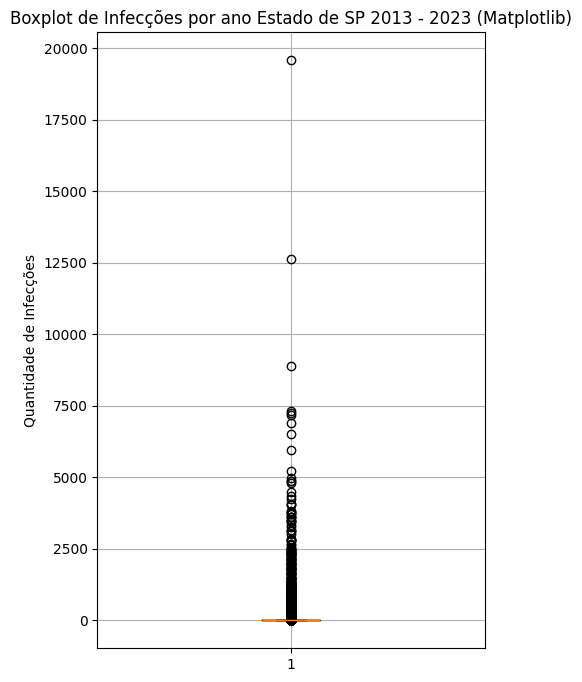

In [ ]:
#enxergando em Seaborn
plt.figure(figsize=(5, 8))
plt.boxplot(df_sp["qtd_infeccoes"], vert=True)
plt.title("Boxplot de Infecções por ano Estado de SP 2013 - 2023 (Matplotlib)")
plt.ylabel("Quantidade de Infecções")
plt.grid(True)
plt.show()

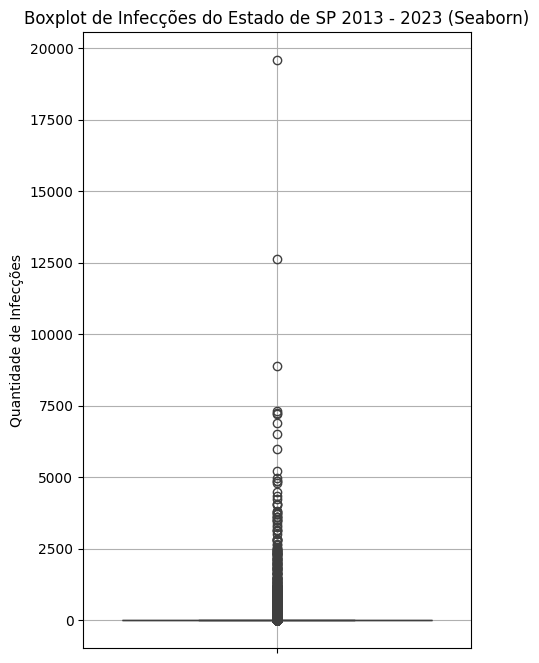

In [ ]:
plt.figure(figsize=(5, 8))
sns.boxplot(y=df_sp["qtd_infeccoes"])
plt.title("Boxplot de Infecções do Estado de SP 2013 - 2023 (Seaborn)")
plt.ylabel("Quantidade de Infecções")
plt.grid(True)
plt.show()

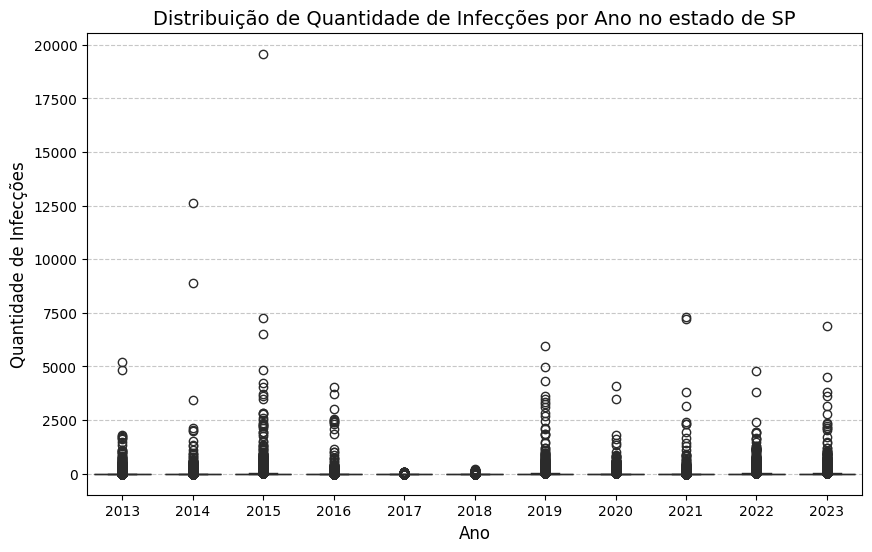

In [ ]:
#vamos criar um gráfico boxplot personalizado para análise
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sp, x='ano', y='qtd_infeccoes', palette='viridis')
plt.title('Distribuição de Quantidade de Infecções por Ano no estado de SP', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Infecções', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Antes de criarmos o gráfico de barras precisamos criar uma tabela com a soma das infecções por ano, pois se não o seanborn nos devolve a média.

In [ ]:
infeccoes_ano = (df_sp.groupby("ano")["qtd_infeccoes"].sum().reset_index())

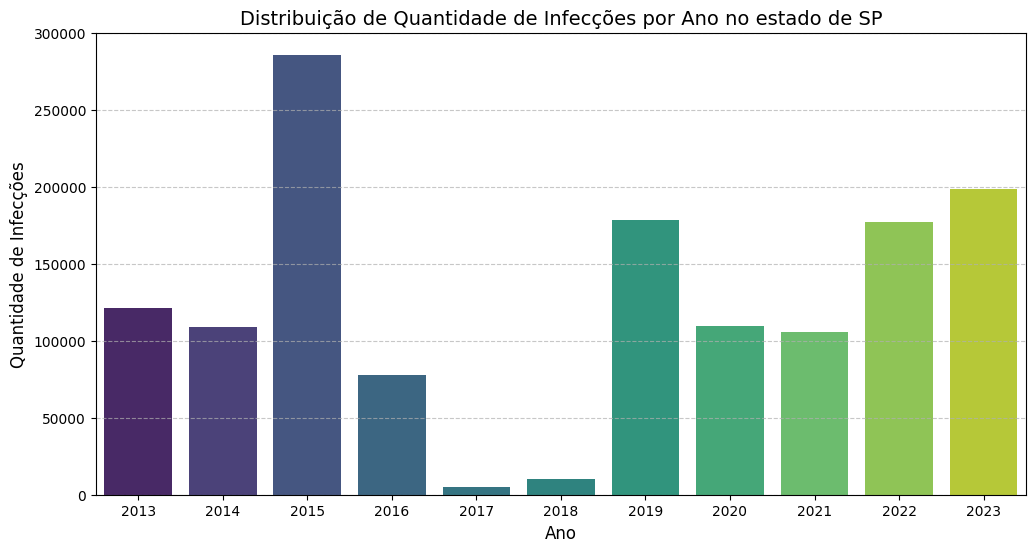

In [ ]:
#vamos criar um gráfico de barras personalizado para análise

plt.figure(figsize=(12, 6))
sns.barplot(data=infeccoes_ano, x='ano', y='qtd_infeccoes', palette='viridis')
plt.title('Distribuição de Quantidade de Infecções por Ano no estado de SP', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Infecções', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Interpretação

Com base nesse gráfico podemos ver que o ano com o maior numero de infecções no estado de São Paulo foi em 2015 e o ano com menor número de infecções foi em 2017.

In [ ]:
infeccoes_ano = (df_sp.groupby("ano")["qtd_infeccoes"].sum().reset_index())

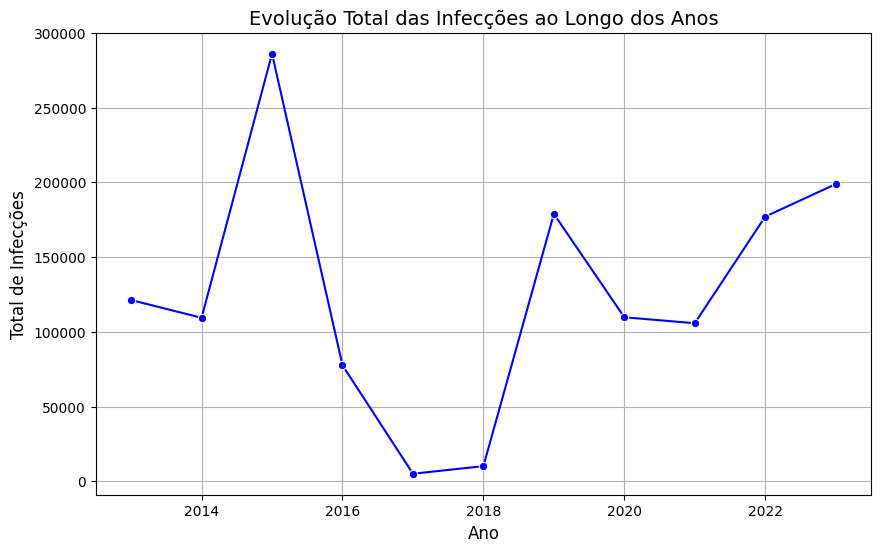

In [ ]:
# Vamos criar um gráfico de linha também
plt.figure(figsize=(10, 6))
sns.lineplot(data=infeccoes_ano, x="ano", y="qtd_infeccoes", marker="o", color="blue")
plt.title("Evolução Total das Infecções ao Longo dos Anos", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Total de Infecções", fontsize=12)
plt.grid(True)
plt.show()


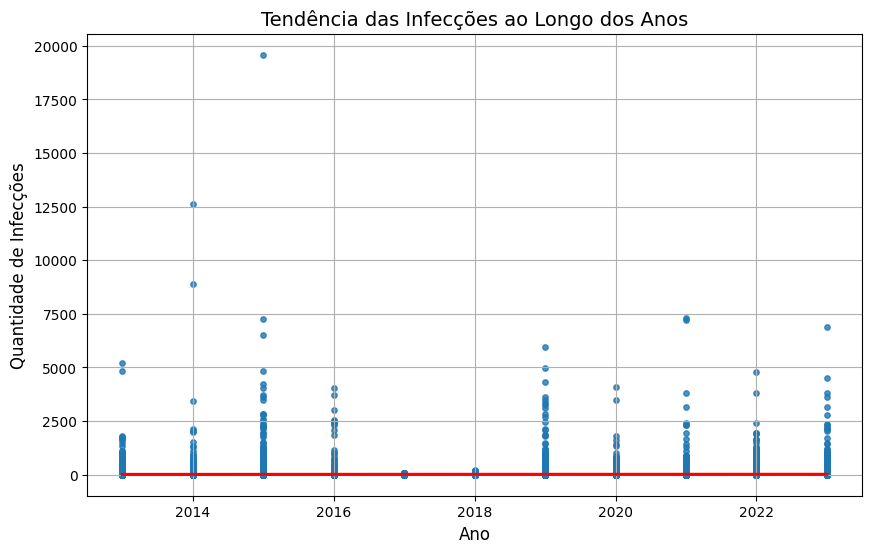

In [ ]:
# Vamos criar um gráfico personalizado de regressão linear simples usando Seaborn
plt.figure(figsize=(10, 6))
sns.regplot(data=df_sp, x="ano", y="qtd_infeccoes", scatter_kws={"s": 15}, line_kws={"color": "red"})
plt.title("Tendência das Infecções ao Longo dos Anos", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Infecções", fontsize=12)
plt.grid(True)
plt.show()


###Quais municípios de SP: concentram mais casos de 2013 até 2023? (Top 10)


Para isso precisamos primeiro saber a quantidade total de infecções de todos os municípios de SP, ou seja, a somatória total de 2013 até 2023 de cada municipio.

In [ ]:
infeccoes_total_municipio = (infeccoes_municipio_sp.groupby("municipio")["qtd_infeccoes"].sum().reset_index()).sort_values(by="qtd_infeccoes", ascending=False)

In [ ]:
display(infeccoes_total_municipio.head())
display(infeccoes_total_municipio.tail())


,municipio,qtd_infeccoes
564,SAO PAULO,138048
558,SAO JOSE DO RIO PRETO,75073
489,RIBEIRAO PRETO,46014
466,PRESIDENTE PRUDENTE,43649
67,BAURU,38764


,municipio,qtd_infeccoes
370,NOVA CAMPINA,3
633,VARGEM,2
80,BOM SUCESSO DE ITARARE,1
255,ITAOCA,1
60,BARRA DO CHAPEU,0


Agora vamos separar os top 10 com mais infecções

In [ ]:
top10_mais_infeccoes = infeccoes_total_municipio.head(10)


In [ ]:
top10_mais_infeccoes

,municipio,qtd_infeccoes
564,SAO PAULO,138048
558,SAO JOSE DO RIO PRETO,75073
489,RIBEIRAO PRETO,46014
466,PRESIDENTE PRUDENTE,43649
67,BAURU,38764
583,SOROCABA,29049
108,CAMPINAS,26189
214,GUARULHOS,23911
605,TATUI,19914
328,MARILIA,19321


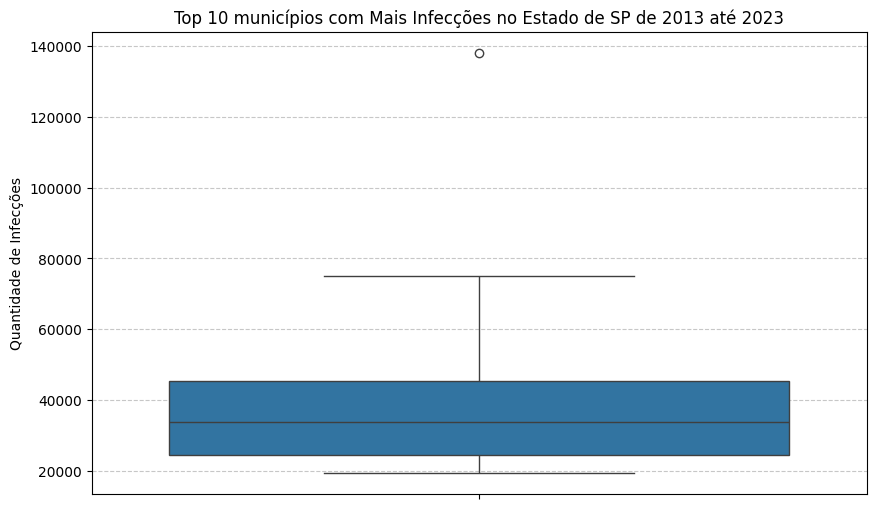

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=top10_mais_infeccoes, y='qtd_infeccoes')
plt.title('Top 10 municípios com Mais Infecções no Estado de SP de 2013 até 2023')
plt.ylabel('Quantidade de Infecções')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

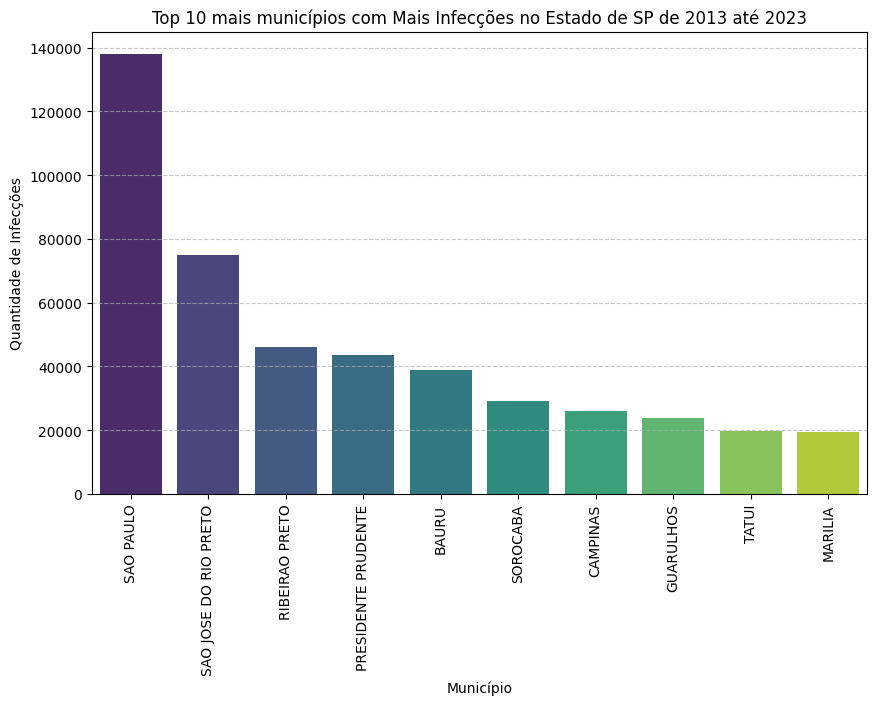

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_mais_infeccoes, x='municipio', y='qtd_infeccoes', palette='viridis')
plt.title('Top 10 mais municípios com Mais Infecções no Estado de SP de 2013 até 2023')
plt.xlabel('Município')
plt.ylabel('Quantidade de Infecções')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.show()


Interpretação

A cidade de São Paulo apresntou o maior número de casos no período de 2013 até 2023, tendo quase o dobro do segundo colocado.

###Quais municípios concentram menos casos de infecções de 2013 até 2023? (Top 10)

In [ ]:
top10_menos_infeccoes = infeccoes_total_municipio.tail(10)

In [ ]:
top10_menos_infeccoes

,municipio,qtd_infeccoes
607,TEJUPA,7
617,TUIUTI,6
481,RIBEIRA,6
416,PEDRA BELA,4
261,ITAPIRAPUA PAULISTA,4
370,NOVA CAMPINA,3
633,VARGEM,2
80,BOM SUCESSO DE ITARARE,1
255,ITAOCA,1
60,BARRA DO CHAPEU,0


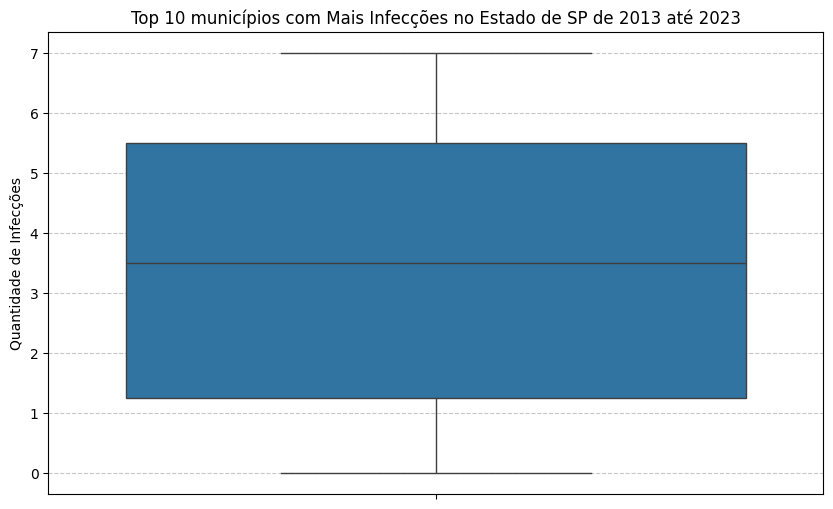

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=top10_menos_infeccoes, y='qtd_infeccoes')
plt.title('Top 10 municípios com Mais Infecções no Estado de SP de 2013 até 2023')
plt.ylabel('Quantidade de Infecções')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

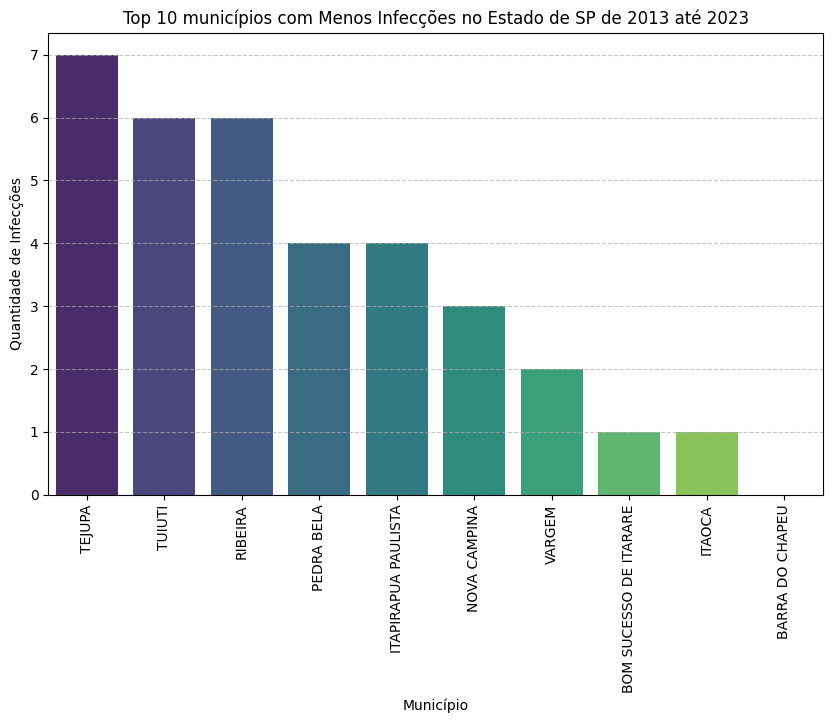

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_menos_infeccoes, x='municipio', y='qtd_infeccoes', palette='viridis')
plt.title('Top 10 municípios com Menos Infecções no Estado de SP de 2013 até 2023')
plt.xlabel('Município')
plt.ylabel('Quantidade de Infecções')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

Interpretação

As cidades que menos apresentaram casos de infecção são interioranas

###Como a cidade de São Paulo se comportou nesse período? (2013 - 2023)

In [ ]:
#vamos começar filtrando apenas a cidade de SP
cidade_sp = df_sp[df_sp["municipio"] == "SAO PAULO"]

In [ ]:
cidade_sp.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
504768,SAO PAULO,SP,2013-01-01,263,2013
504769,SAO PAULO,SP,2013-02-01,397,2013
504770,SAO PAULO,SP,2013-03-01,1088,2013
504771,SAO PAULO,SP,2013-04-01,1618,2013
504772,SAO PAULO,SP,2013-05-01,722,2013


In [ ]:
#agora agrupamos por ano
infeccoes_cidade_sp = (cidade_sp.groupby("ano")["qtd_infeccoes"].sum().reset_index())


In [ ]:
infeccoes_cidade_sp.head()

,ano,qtd_infeccoes
0,2013,4660
1,2014,29049
2,2015,35427
3,2016,14946
4,2017,444


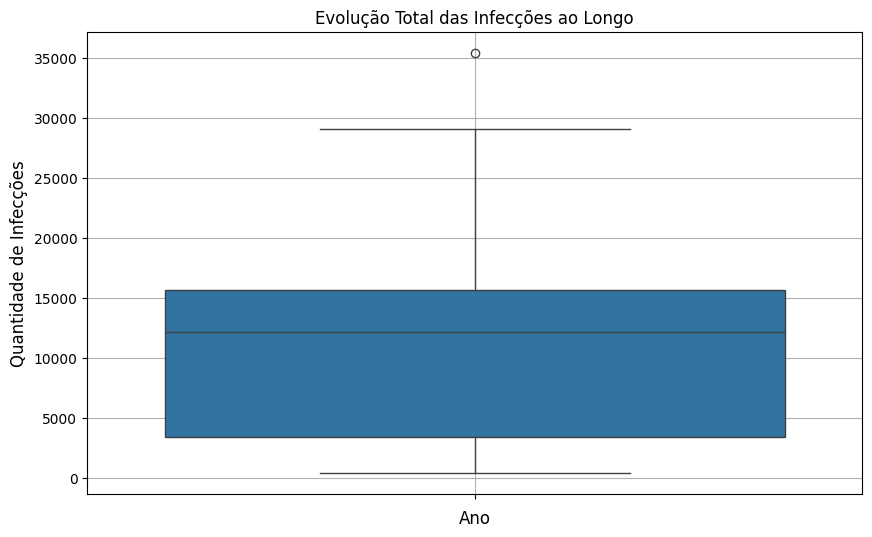

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=infeccoes_cidade_sp, y="qtd_infeccoes")
plt.title("Evolução Total das Infecções ao Longo")
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Infecções", fontsize=12)
plt.grid(True)
plt.show()

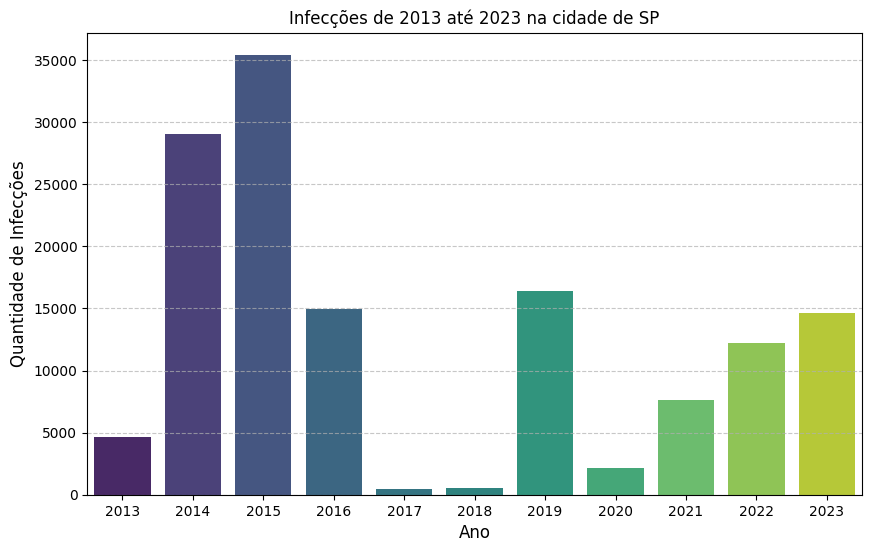

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=infeccoes_cidade_sp, x="ano", y="qtd_infeccoes", palette="viridis")
plt.title("Infecções de 2013 até 2023 na cidade de SP")
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Infecções", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Interpretação

A cidade de SP teve comportamento semelhante ao estado de SP, que apresentou maior taxa de infecção em 2015 e menor taxa em 2017. Considerando que a análise contempla 645 municípios do estado de SP, só a cidade de São paulo foi responsável por quase 12% do total das infecções do estado.

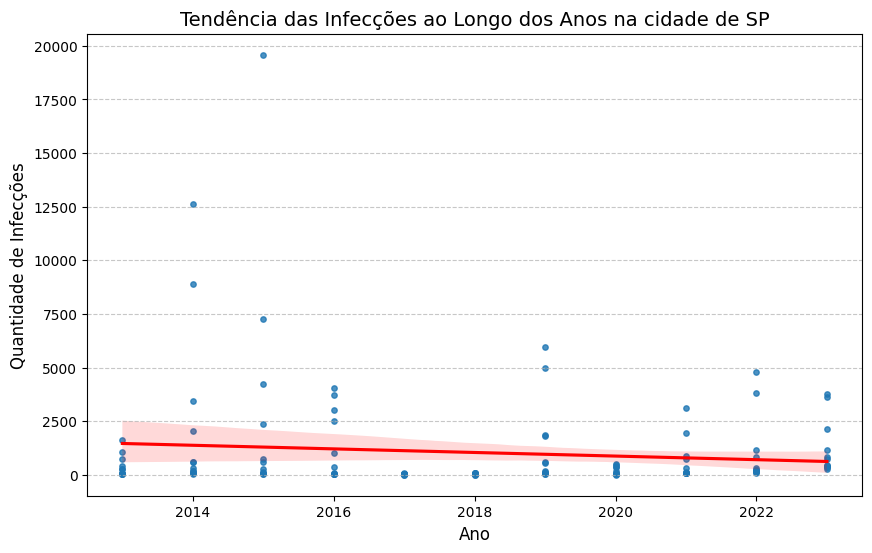

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=cidade_sp, x="ano", y="qtd_infeccoes", scatter_kws={"s": 15}, line_kws={"color": "red"})
plt.title("Tendência das Infecções ao Longo dos Anos na cidade de SP", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Infecções", fontsize=12)
plt.grid(axis= 'y', linestyle='--', alpha=0.7)
plt.show()

###Calculando as taxas de infecção por 100 mil habitantes no estado de SP

Iremos analisar os anos de 2013 e 2023 para ver o comportamento dos municípios na decada e de 2015 para ver o comportamento da cidade de SP que teve seu pico de infecções nesse ano.

Começamos preparando o ambiente, lendo os arquivos e confererindo

In [ ]:
df_populacao = pd.read_excel('Populacao_2013_2023.xlsx')

In [ ]:
df_populacao.head()

,Município,uf,População 2013,População 2014,População 2015,População 2016,População 2017,População 2018,População 2019,População 2020,População 2021,População 2022,População 2023
0,ALTA FLORESTA D'OESTE,RO,25728,25652,25578,25506,25437,23167,22945,22728,22516,21494,21494
1,ARIQUEMES,RO,101269,102860,104401,105896,107345,106168,107863,109523,111148,96833,96833
2,CABIXI,RO,6495,6424,6355,6289,6224,5438,5312,5188,5067,5351,5351
3,CACOAL,RO,85863,86556,87226,87877,88507,84813,85359,85893,86416,86887,86887
4,CEREJEIRAS,RO,18041,18013,17986,17959,17934,16444,16323,16204,16088,15890,15890


Depois filtramos epenas os municípios do estado de SP

In [ ]:
df_populacao_sp = df_populacao[df_populacao['uf'] == 'SP']

In [ ]:
df_populacao_sp.head()

,Município,uf,População 2013,População 2014,População 2015,População 2016,População 2017,População 2018,População 2019,População 2020,População 2021,População 2022,População 2023
3262,ADAMANTINA,SP,34953,35001,35048,35094,35139,35023,35068,35111,35153,34687,34687
3263,ADOLFO,SP,3639,3631,3623,3616,3609,3571,3562,3554,3545,4351,4351
3264,AGUAI,SP,34188,34530,34863,35189,35508,35954,36305,36648,36981,32072,32072
3265,AGUAS DA PRATA,SP,7942,7984,8025,8065,8104,8137,8180,8221,8262,7369,7369
3266,AGUAS DE LINDOIA,SP,18108,18212,18313,18412,18509,18599,18705,18808,18908,17930,17930


Filtramos as populações de 2013 e 2023

In [ ]:
df_populacao_2013 = df_populacao_sp[['uf', 'Município', 'População 2013']]
df_populacao_2015 = df_populacao_sp[['uf', 'Município', 'População 2015']]
df_populacao_2023 = df_populacao_sp[['uf', 'Município', 'População 2023']]

In [ ]:
df_populacao_2013.head()

,uf,Município,População 2013
3262,SP,ADAMANTINA,34953
3263,SP,ADOLFO,3639
3264,SP,AGUAI,34188
3265,SP,AGUAS DA PRATA,7942
3266,SP,AGUAS DE LINDOIA,18108


In [ ]:
df_populacao_2015.head()

,uf,Município,População 2015
3262,SP,ADAMANTINA,35048
3263,SP,ADOLFO,3623
3264,SP,AGUAI,34863
3265,SP,AGUAS DA PRATA,8025
3266,SP,AGUAS DE LINDOIA,18313


In [ ]:
df_populacao_2023.head()


,uf,Município,População 2023
3262,SP,ADAMANTINA,34687
3263,SP,ADOLFO,4351
3264,SP,AGUAI,32072
3265,SP,AGUAS DA PRATA,7369
3266,SP,AGUAS DE LINDOIA,17930


Filtramos as infecções dos municípios de SP que ocorreram em 2013

In [ ]:
infeccoes_municipio_sp_2013 = df_sp[df_sp['ano'] == 2013].groupby('municipio')['qtd_infeccoes'].sum().reset_index().sort_values(by='qtd_infeccoes', ascending=False)


In [ ]:
infeccoes_municipio_sp_2013.head()

,municipio,qtd_infeccoes
558,SAO JOSE DO RIO PRETO,14194
67,BAURU,5256
564,SAO PAULO,4660
489,RIBEIRAO PRETO,4075
466,PRESIDENTE PRUDENTE,3933


Filtramos as infecções dos municípios de SP que ocorreram em 2015

In [ ]:
infeccoes_municipio_sp_2015 = df_sp[df_sp['ano'] == 2015].groupby('municipio')['qtd_infeccoes'].sum().reset_index().sort_values(by='qtd_infeccoes', ascending=False)

In [ ]:
infeccoes_municipio_sp_2015.head()

,municipio,qtd_infeccoes
564,SAO PAULO,35427
583,SOROCABA,15084
558,SAO JOSE DO RIO PRETO,11569
214,GUARULHOS,9970
305,LIMEIRA,7971


Filtramos as infecções dos municípios de SP que ocorreram em 2023

In [ ]:
infeccoes_municipio_sp_2023 = df_sp[df_sp['ano'] == 2023].groupby('municipio')['qtd_infeccoes'].sum().reset_index().sort_values(by='qtd_infeccoes', ascending=False)


In [ ]:
infeccoes_municipio_sp_2023.head()

,municipio,qtd_infeccoes
466,PRESIDENTE PRUDENTE,16494
564,SAO PAULO,14607
489,RIBEIRAO PRETO,8742
67,BAURU,8560
583,SOROCABA,5677


Ju\ntamos as planilhas de população e infecções de 2013

In [ ]:
df_dengue_pop_2013 = pd.merge(infeccoes_municipio_sp_2013, df_populacao_2013, left_on='municipio', right_on='Município')

Excluímos a coluna Município que ficou redundante

In [ ]:
df_dengue_pop_2013 = df_dengue_pop_2013.drop(columns=['Município'])

In [ ]:
df_dengue_pop_2013.head()

,municipio,qtd_infeccoes,uf,População 2013
0,SAO JOSE DO RIO PRETO,14194,SP,434039
1,BAURU,5256,SP,362062
2,SAO PAULO,4660,SP,11821873
3,RIBEIRAO PRETO,4075,SP,649556
4,PRESIDENTE PRUDENTE,3933,SP,218960


Ju\ntamos as planilhas de população e infecções de 2015




In [ ]:
df_dengue_pop_2015 = pd.merge(infeccoes_municipio_sp_2015, df_populacao_2015, left_on='municipio', right_on='Município')

Excluímos a coluna Município que ficou redundante

In [ ]:
df_dengue_pop_2015 = df_dengue_pop_2015.drop(columns=['Município'])

In [ ]:
df_dengue_pop_2015.head()

,municipio,qtd_infeccoes,uf,População 2015
0,SAO PAULO,35427,SP,11967825
1,SOROCABA,15084,SP,644919
2,SAO JOSE DO RIO PRETO,11569,SP,442548
3,GUARULHOS,9970,SP,1324781
4,LIMEIRA,7971,SP,296440


Juntamos as planilhas de população e infecção de 2023

In [ ]:
df_dengue_pop_2023 = pd.merge(infeccoes_municipio_sp_2023, df_populacao_2023, left_on='municipio', right_on='Município')

Excluímos a coluna Município que ficou redundante

In [ ]:
df_dengue_pop_2023 = df_dengue_pop_2023.drop(columns=['Município'])

In [ ]:
df_dengue_pop_2023.head()

,municipio,qtd_infeccoes,uf,População 2023
0,PRESIDENTE PRUDENTE,16494,SP,225668
1,SAO PAULO,14607,SP,11451999
2,RIBEIRAO PRETO,8742,SP,698642
3,BAURU,8560,SP,379146
4,SOROCABA,5677,SP,723682


Calculamos a taxa de infecção por 100 mil habitantes, dividindo a quantidade de infecções pela população.

In [ ]:
# 1. Cria a coluna com o cálculo das infecções por 100 mil habitantes
df_dengue_pop_2013['infeccoes por 100mil'] = round((df_dengue_pop_2013['qtd_infeccoes'] / df_dengue_pop_2013['População 2013']) * 100000)

# 2. Ordena a tabela inteira deixando o maior índice de infecção no topo
df_dengue_pop_2013 = df_dengue_pop_2013.sort_values(by='infeccoes por 100mil', ascending=False)

In [ ]:
df_dengue_pop_2013.head()

,municipio,qtd_infeccoes,uf,População 2013,infeccoes por 100mil
148,PONTES GESTAL,141,SP,2593,5438.0
123,PLANALTO,197,SP,4808,4097.0
0,SAO JOSE DO RIO PRETO,14194,SP,434039,3270.0
13,ITUVERAVA,1311,SP,40552,3233.0
40,PARIQUERA-ACU,607,SP,19239,3155.0


In [ ]:
# 1. Cria a coluna com o cálculo das infecções por 100 mil habitantes
df_dengue_pop_2015['infeccoes por 100mil'] = round((df_dengue_pop_2015['qtd_infeccoes'] / df_dengue_pop_2015['População 2015']) * 100000)

# 2. Ordena a tabela inteira deixando o maior índice de infecção no topo
df_dengue_pop_2015 = df_dengue_pop_2015.sort_values(by='infeccoes por 100mil', ascending=False)

In [ ]:
df_dengue_pop_2015.head()

,municipio,qtd_infeccoes,uf,População 2015,infeccoes por 100mil
65,ESTRELA D'OESTE,776,SP,8462,9170.0
284,TRABIJU,121,SP,1664,7272.0
279,CRUZALIA,125,SP,2209,5659.0
160,MENDONCA,284,SP,5161,5503.0
179,JULIO MESQUITA,253,SP,4687,5398.0


In [ ]:
# 1. Cria a coluna com o cálculo das infecções por 100 mil habitantes
df_dengue_pop_2023['infeccoes por 100mil'] = round((df_dengue_pop_2023['qtd_infeccoes'] / df_dengue_pop_2023['População 2023']) * 100000)

# 2. Ordena a tabela inteira deixando o maior índice de infecção no topo
df_dengue_pop_2023 = df_dengue_pop_2023.sort_values(by='infeccoes por 100mil', ascending=False)

In [ ]:
df_dengue_pop_2023.head()

,municipio,qtd_infeccoes,uf,População 2023,infeccoes por 100mil
29,PRESIDENTE BERNARDES,1369,SP,4850,28227.0
72,AMPARO,571,SP,2234,25560.0
36,RIBEIRAO DO SUL,1166,SP,4677,24931.0
57,OCAUCU,706,SP,4331,16301.0
149,FLORA RICA,235,SP,1487,15804.0


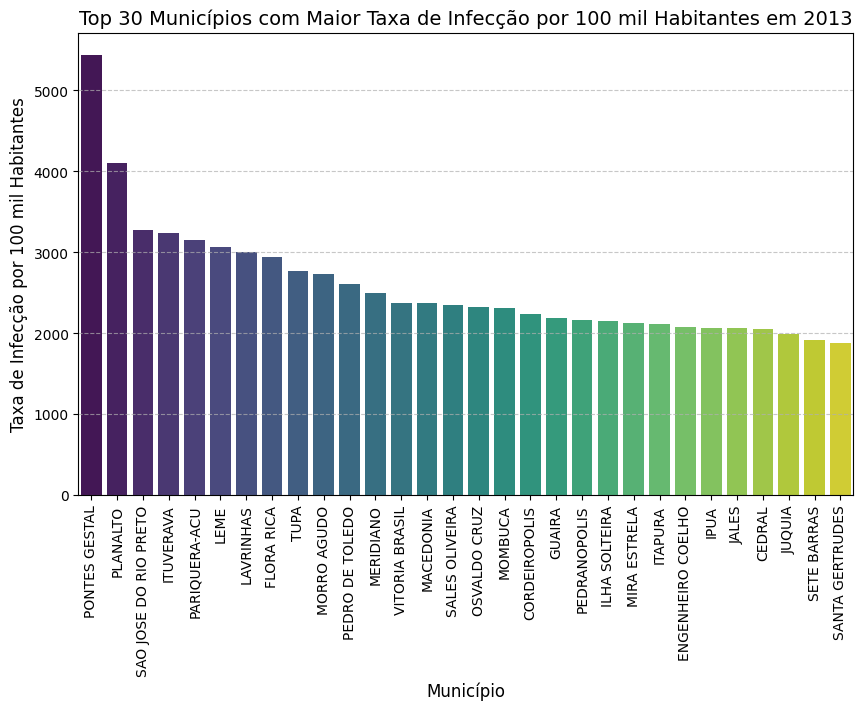

In [ ]:
# Ordenar os dados do maior para o menor número de infecções
tx_infeccao_2013 = df_dengue_pop_2013.sort_values(by='infeccoes por 100mil', ascending=False).head(30)

# Criar gráfico de barras ordenado
plt.figure(figsize=(10, 6))
sns.barplot(data=tx_infeccao_2013, x='municipio', y='infeccoes por 100mil', palette='viridis')

# Personalizar o gráfico
plt.title('Top 30 Municípios com Maior Taxa de Infecção por 100 mil Habitantes em 2013', fontsize=14)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Taxa de Infecção por 100 mil Habitantes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

Interpretação

Podemos perceber que ao analisar as infecções de 2013 a cidade de SP não aparece entre as top 30.

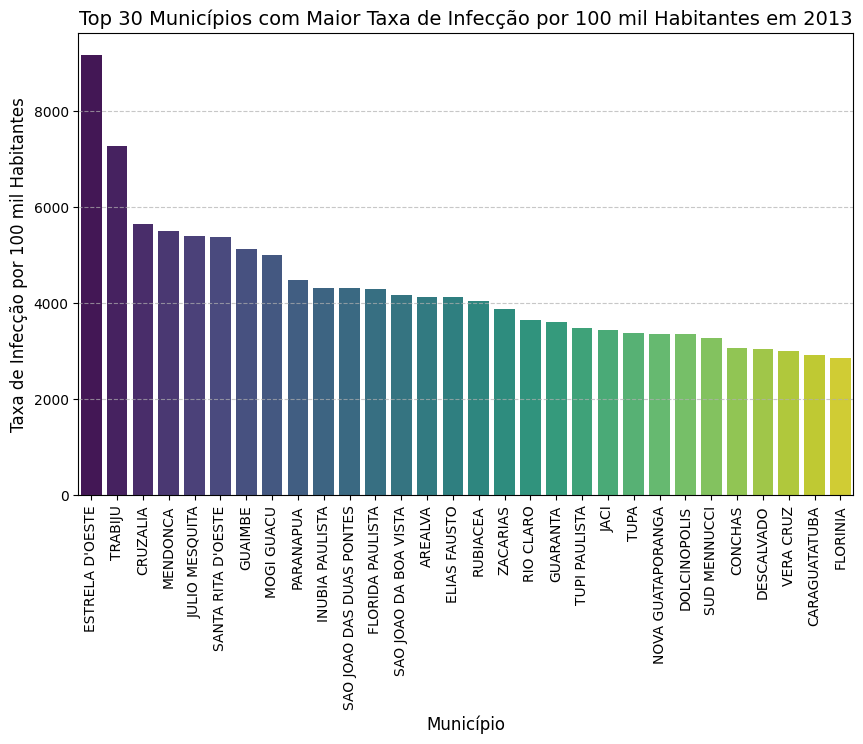

In [ ]:
# Ordenar os dados do maior para o menor número de infecções
tx_infeccao_2015 = df_dengue_pop_2015.sort_values(by='infeccoes por 100mil', ascending=False).head(30)

# Criar gráfico de barras ordenado
plt.figure(figsize=(10, 6))
sns.barplot(data=tx_infeccao_2015, x='municipio', y='infeccoes por 100mil', palette='viridis')

# Personalizar o gráfico
plt.title('Top 30 Municípios com Maior Taxa de Infecção por 100 mil Habitantes em 2013', fontsize=14)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Taxa de Infecção por 100 mil Habitantes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

Interpretação

nem mesmo em 2015 que a cidade de SP apresentou o maior numero de infecções ela aparece no top 30 das maiores infecções por 100 mil habitantes

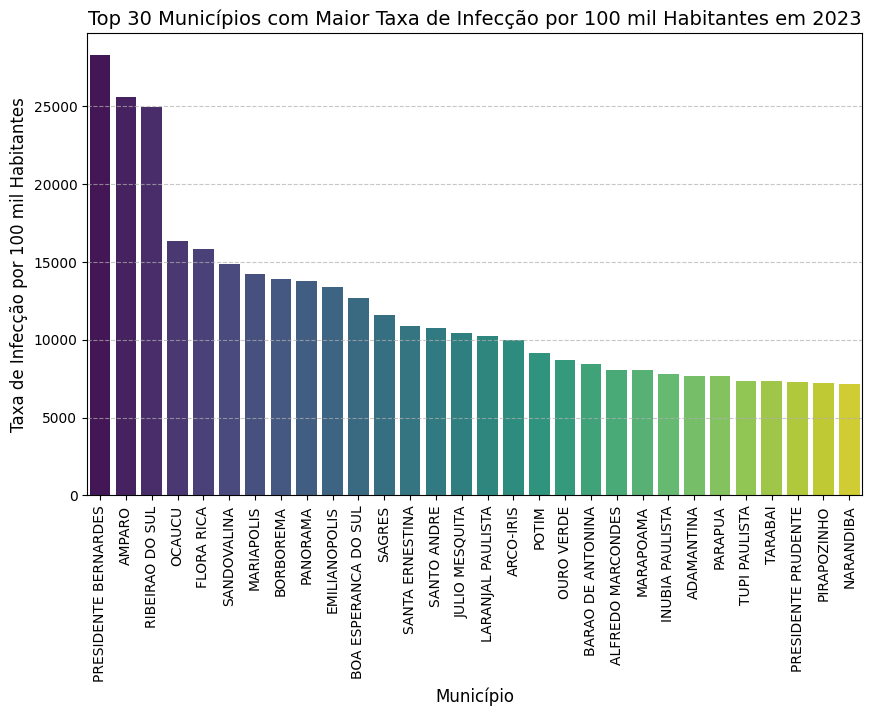

In [ ]:
# Ordenar os dados do maior para o menor número de infecções
tx_infeccao_2023 = df_dengue_pop_2023.sort_values(by='infeccoes por 100mil', ascending=False).head(30)

# Criar gráfico de barras ordenado
plt.figure(figsize=(10, 6))
sns.barplot(data=tx_infeccao_2023, x='municipio', y='infeccoes por 100mil', palette='viridis')

# Personalizar o gráfico
plt.title('Top 30 Municípios com Maior Taxa de Infecção por 100 mil Habitantes em 2023', fontsize=14)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Taxa de Infecção por 100 mil Habitantes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

Interpretação

em 2023 as cidades que mais apresentaram maior taxa de infecção por 100 mil habitantes, foram as cidades do interior.